# SIM 1010s — Shear localization analysis

Simulations 1010–1019: hexagonal random foam compressed at 10 internal pressure levels

Pressure series: `P = [0.0] + [0.004 x sqrt(2)^i for i in 0..8]`

**Plots**
1. Shear mean (TP) vs compressive displacement from t=0 — localization point marked
2. Standard deviation of shear (element-to-element spread of the per-element shear field) vs compressive displacement from t=0 — localization point marked
3. d(Shear mean)/d(displacement) vs compressive displacement from t=0
4. d(Shear std)/d(displacement) vs compressive displacement from t=0
5. J mean (dilatational part of shear) vs compressive displacement from t=0 — localization point marked
6. Distortion mean (distortional part of shear) vs compressive displacement from t=0 — localization point marked
7. eta_shear (area-weighted shear homogeneity index) vs compressive displacement from t=0 — localization point marked
8. eta (element-area homogeneity index) vs compressive displacement from t=0 — localization point marked
9. etaC_A, etaC_R (hole-based area/aspect-ratio localization indices) vs compressive displacement from t=0 — localization point marked
10. w_cv (strain-energy-density coefficient of variation) vs compressive displacement from t=0 — localization point marked

The shear field is `shear_e(t) = 0.5 * trace(F_e(t)^T F_e(t))` (see `docs/T2_REFERENCE.md`).
`shear_mean` is precomputed in the light `DATA_PICK_{sim}_TP2_L.pkl` files, but its
per-element standard deviation is not — it has to be recomputed from the full
per-element `shear` field in `DATA_PICK_{sim}_TP2.pkl`. Those files are ~3.2 GB each,
so the per-sim mean/std curves are computed once and cached to a small pickle
(`shear_std_cache_1010s.pkl`) next to this notebook.

Plots 5 and 6 decompose `shear_e = |J_e| + distortion_e`, where `J_e = det(F_e)` and
`distortion_e = 1/2*(lambda1-lambda2)^2` (lambda1, lambda2 = singular values of `F_e`).
Cached the same way, to `J_distortion_cache_1010s.pkl`.

Plots 7-10 are shear-band / localization *heterogeneity* indices, all already precomputed and living in the light `DATA_PICK_{sim}_TP2_L.pkl` / `DATA_PICK_{sim}_DEFC2.pkl` files — no need for the expensive full-`TP2.pkl` caches used above. Each is a `1 - std/std_i` homogeneity measure (1 = perfectly uniform deformation field, dropping as the field becomes heterogeneous/localized), applied to a different quantity: area-weighted shear (`eta_shear`), raw element area (`eta`), hole area and hole aspect ratio (`etaC_A`, `etaC_R`). `w_cv` is the coefficient of variation (std/mean) of strain-energy density across elements (param set `(K,G,m,n) = (1,1,1,1)`), which rises rather than falls as deformation localizes.

In [1]:
import sys, os, pickle, json
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = '../I001_Results'
OBJ_DIR     = '../I001_Results/OBJ_files'
SIMS        = list(range(1010, 1020))
CACHE_PATH  = 'shear_std_cache_1010s.pkl'


In [2]:
def load_pkl(path):
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    # Fall back to the alternate results directory pointed to by
    # I001_Results/AAA_fwd (a plain-text file holding a redirect path),
    # e.g. when results were moved off this machine but the analysis
    # notebooks still reference the local RESULTS_DIR layout.
    fwd_file = os.path.join(RESULTS_DIR, 'AAA_fwd')
    if os.path.exists(fwd_file):
        with open(fwd_file) as f:
            fwd_dir = f.read().strip()
        fwd_path = os.path.join(fwd_dir, os.path.relpath(path, RESULTS_DIR))
        if os.path.exists(fwd_path):
            with open(fwd_path, 'rb') as f:
                return pickle.load(f)
    return None

def resolve_path(path):
    """Same AAA_fwd redirect fallback as load_pkl(), but returns a path
    instead of loading the file (needed for the full TP2.pkl cache builders,
    which open and stream the file themselves)."""
    if os.path.exists(path):
        return path
    fwd_file = os.path.join(RESULTS_DIR, 'AAA_fwd')
    if os.path.exists(fwd_file):
        with open(fwd_file) as f:
            fwd_dir = f.read().strip()
        fwd_path = os.path.join(fwd_dir, os.path.relpath(path, RESULTS_DIR))
        if os.path.exists(fwd_path):
            return fwd_path
    return None

def get_pressure(sim):
    path = resolve_path(os.path.join(OBJ_DIR, f'SIM_{sim:03d}.json'))
    if path is None:
        return None
    with open(path) as f:
        d = json.load(f)
    for step in d.get('steps', []):
        pb = step.get('Pressure_BC', 0)
        if pb:
            return float(pb)
    return 0.0


In [3]:
PRESSURES = {sim: get_pressure(sim) for sim in SIMS}
print({sim: f'{p:.6f} MPa' for sim, p in PRESSURES.items()})


{1010: '0.000000 MPa', 1011: '0.040000 MPa', 1012: '0.056569 MPa', 1013: '0.080000 MPa', 1014: '0.113137 MPa', 1015: '0.160000 MPa', 1016: '0.226274 MPa', 1017: '0.320000 MPa', 1018: '0.452548 MPa', 1019: '0.640000 MPa'}


In [4]:
from matplotlib.lines import Line2D

def mark_localizations(ax, color, sim, displ, y):
    if sim in LOC_A:
        xA = LOC_A[sim]
        yA = np.interp(xA, displ, y)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=color, linewidths=1.8, zorder=5)

def add_localization_legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    if LOC_A:
        handles.append(Line2D([], [], marker='v', linestyle='None', markerfacecolor='none', markeredgecolor='k', markersize=8))
        labels.append('Localization A')
    return handles, labels


## Localization point

Same convention as `SIM_1010s_analysis.ipynb`: Localization A is the displacement at
the minimum of `shear_mean`, per sim.

In [5]:
# LocalizationA = displacement at the minimum of shear_mean, per sim.
LOC_A = {}

for sim in SIMS:
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l

    idx_min = np.argmin(shear_mean)
    LOC_A[sim] = displ[idx_min]

LOC_A


{1010: 2.450000047683716,
 1011: 2.7649455070495605,
 1012: 2.869150161743164,
 1013: 3.0453219413757324,
 1014: 3.2962982654571533,
 1015: 3.6289710998535156,
 1016: 4.058625221252441,
 1017: 4.619215965270996,
 1018: 5.0}

## Shear mean / shear std cache

For each sim, load the full `DATA_PICK_{sim}_TP2.pkl`, rebuild the per-element x
per-frame shear array, and reduce it to `shear_mean(t)` and `shear_std(t)` (std across
elements at each frame). This mirrors `shear_mean` in the light file (sanity-checked to
match) and additionally gives the std, which the light file does not carry.

Cached to `shear_std_cache_1010s.pkl` so this expensive step only runs once.

In [6]:
def compute_shear_std_cache():
    cache = {}
    for sim in SIMS:
        path = resolve_path(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2.pkl'))
        if path is None:
            print(f'SIM {sim}: no full TP2.pkl, skipping')
            continue
        print(f'SIM {sim}: loading full TP2.pkl (~3 GB, this can take ~30-60s)...')
        with open(path, 'rb') as f:
            tp2 = pickle.load(f)

        t = np.array(tp2['t'])
        shear = tp2['shear']
        n_frames = len(t)
        elem_ids = list(shear.keys())

        arr = np.empty((len(elem_ids), n_frames))
        for i, eid in enumerate(elem_ids):
            d = shear[eid]
            arr[i, :] = [d[j] for j in range(n_frames)]
        del tp2, shear

        cache[sim] = {
            't': t,
            'shear_mean': arr.mean(axis=0),
            'shear_std': arr.std(axis=0),
        }
        del arr
        print(f'SIM {sim}: done')
    return cache


if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'rb') as f:
        SHEAR_CACHE = pickle.load(f)
else:
    SHEAR_CACHE = compute_shear_std_cache()
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(SHEAR_CACHE, f)

sorted(SHEAR_CACHE.keys())


[1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018]

## Plot 1 — Shear mean (TP) vs compressive displacement from t=0

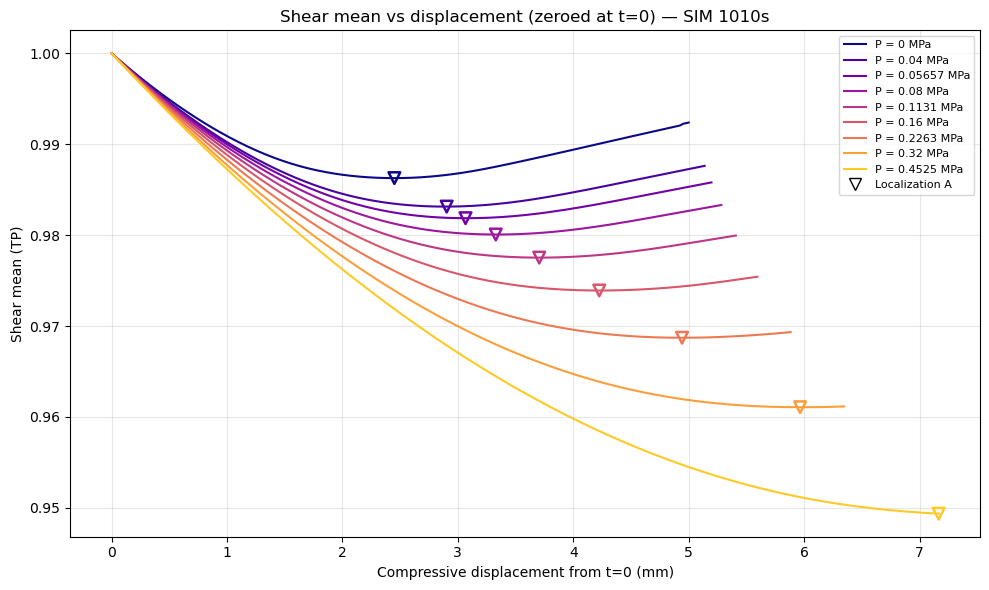

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in SHEAR_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    shear_mean = SHEAR_CACHE[sim]['shear_mean']

    # Zeroed displacement: subtract displ(t=0) so every sim starts at 0,
    # removing the pressure-induced Step-0 expansion offset.
    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, shear_mean, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, shear_mean)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('Shear mean (TP)')
ax.set_title('Shear mean vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 2 — Standard deviation of shear (TP) vs compressive displacement from t=0

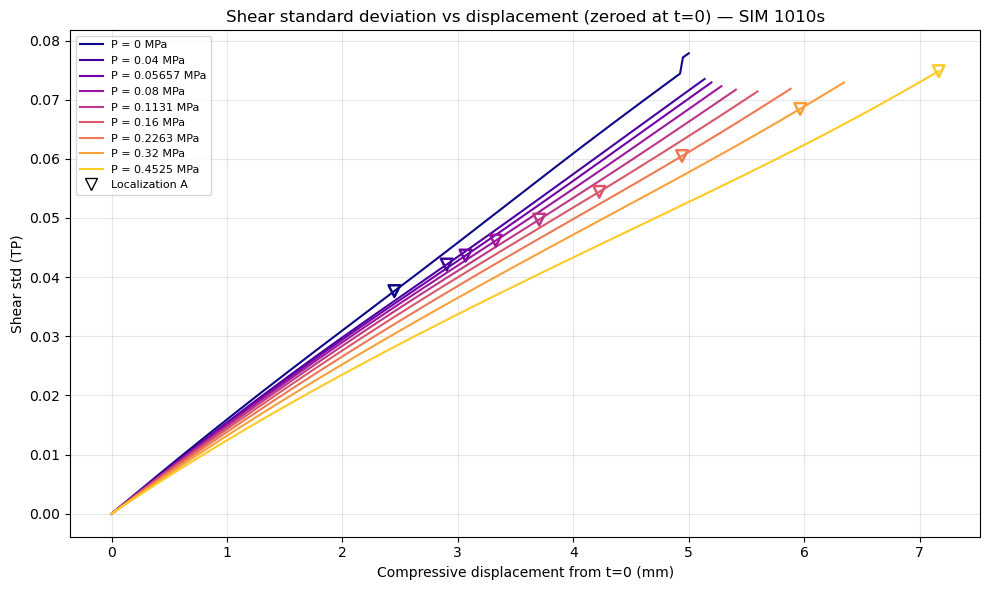

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in SHEAR_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    shear_std = SHEAR_CACHE[sim]['shear_std']

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, shear_std, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, shear_std)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('Shear std (TP)')
ax.set_title('Shear standard deviation vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 3 — d(Shear mean)/d(displacement) vs compressive displacement from t=0

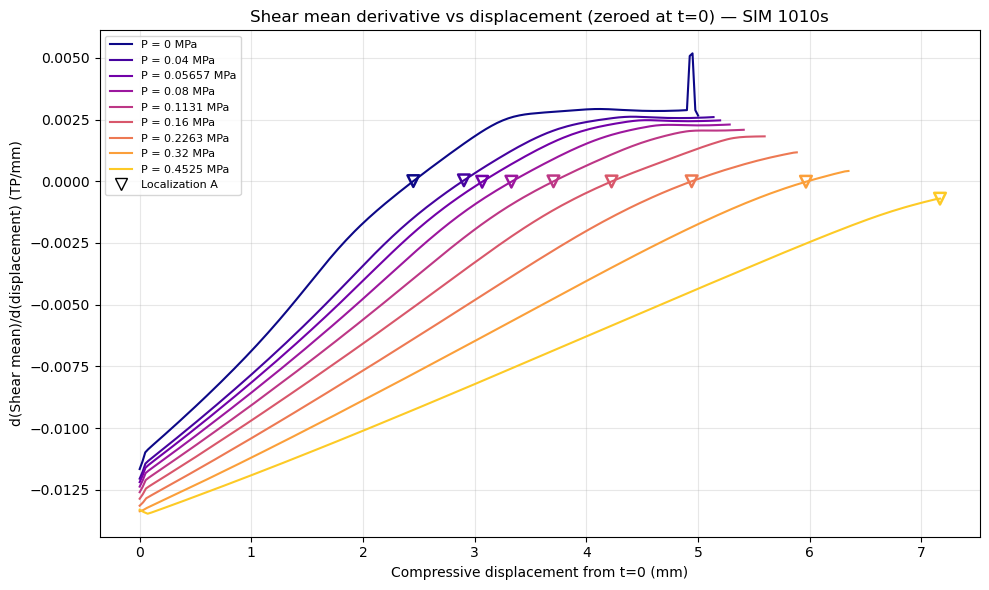

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in SHEAR_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    shear_mean = SHEAR_CACHE[sim]['shear_mean']

    displ0     = displ[0]
    displ_zero = displ - displ0
    dshear_dd  = np.gradient(shear_mean, displ_zero)

    ax.plot(displ_zero, dshear_dd, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, dshear_dd)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('d(Shear mean)/d(displacement) (TP/mm)')
ax.set_title('Shear mean derivative vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 4 — d(Shear std)/d(displacement) vs compressive displacement from t=0

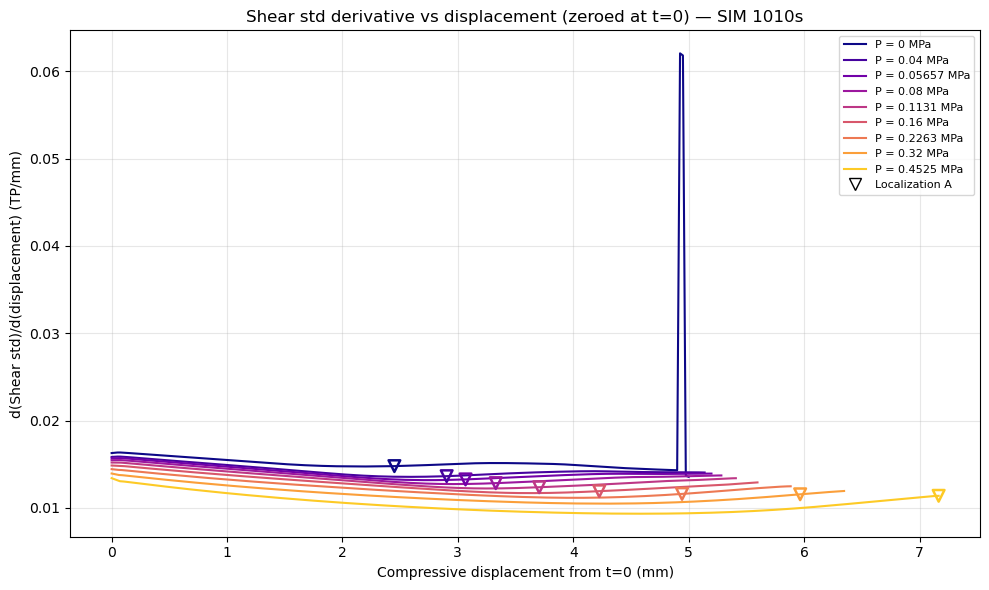

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in SHEAR_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    shear_std = SHEAR_CACHE[sim]['shear_std']

    displ0     = displ[0]
    displ_zero = displ - displ0
    dstd_dd    = np.gradient(shear_std, displ_zero)

    ax.plot(displ_zero, dstd_dd, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, dstd_dd)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('d(Shear std)/d(displacement) (TP/mm)')
ax.set_title('Shear std derivative vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## J / distortion cache

`shear_e(t) = 0.5 * trace(F_e(t)^T F_e(t)) = 0.5*(lambda1^2 + lambda2^2)`, where
lambda1, lambda2 are the singular values (principal stretches) of the per-element
deformation gradient `F_e(t)`. `J_e(t) = det(F_e(t)) = lambda1*lambda2` is already
stored per-element in the full `DATA_PICK_{sim}_TP2.pkl` (key `'J'`), alongside `'shear'`.

Decomposing shear into a dilatational part (J) and a distortional part:

```
distortion = 1/2 * (lambda1 - lambda2)^2
           = 1/2 * (lambda1^2 + lambda2^2) - lambda1*lambda2
           = shear - |J|
```

so `shear = |J| + distortion` — no extra SVD of `F` is needed, `distortion` is read off
directly from the `shear` and `J` fields already in the full TP2 pickle (verified against
an explicit `np.linalg.svd` decomposition of `F`).

Same approach as the shear/std cache above: computed once per sim from the full
`DATA_PICK_{sim}_TP2.pkl` and cached to `J_distortion_cache_1010s.pkl` next to this
notebook.

In [11]:
J_DISTORTION_CACHE_PATH = 'J_distortion_cache_1010s.pkl'

def compute_J_distortion_cache():
    cache = {}
    for sim in SIMS:
        path = resolve_path(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2.pkl'))
        if path is None:
            print(f'SIM {sim}: no full TP2.pkl, skipping')
            continue
        print(f'SIM {sim}: loading full TP2.pkl (~3 GB, this can take ~30-60s)...')
        with open(path, 'rb') as f:
            tp2 = pickle.load(f)

        t        = np.array(tp2['t'])
        shear    = tp2['shear']
        J        = tp2['J']
        n_frames = len(t)
        elem_ids = list(shear.keys())

        shear_arr = np.empty((len(elem_ids), n_frames))
        J_arr     = np.empty((len(elem_ids), n_frames))
        for i, eid in enumerate(elem_ids):
            sd = shear[eid]
            jd = J[eid]
            shear_arr[i, :] = [sd[j] for j in range(n_frames)]
            J_arr[i, :]     = [jd[j] for j in range(n_frames)]
        del tp2, shear, J

        distortion_arr = shear_arr - np.abs(J_arr)

        cache[sim] = {
            't'               : t,
            'shear_mean'      : shear_arr.mean(axis=0),
            'J_mean'          : J_arr.mean(axis=0),
            'distortion_mean' : distortion_arr.mean(axis=0),
        }
        del shear_arr, J_arr, distortion_arr
        print(f'SIM {sim}: done')
    return cache


if os.path.exists(J_DISTORTION_CACHE_PATH):
    with open(J_DISTORTION_CACHE_PATH, 'rb') as f:
        J_DISTORTION_CACHE = pickle.load(f)
else:
    J_DISTORTION_CACHE = compute_J_distortion_cache()
    with open(J_DISTORTION_CACHE_PATH, 'wb') as f:
        pickle.dump(J_DISTORTION_CACHE, f)

sorted(J_DISTORTION_CACHE.keys())


[1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018]

## Plot 5 — J mean (dilatational part) vs compressive displacement from t=0

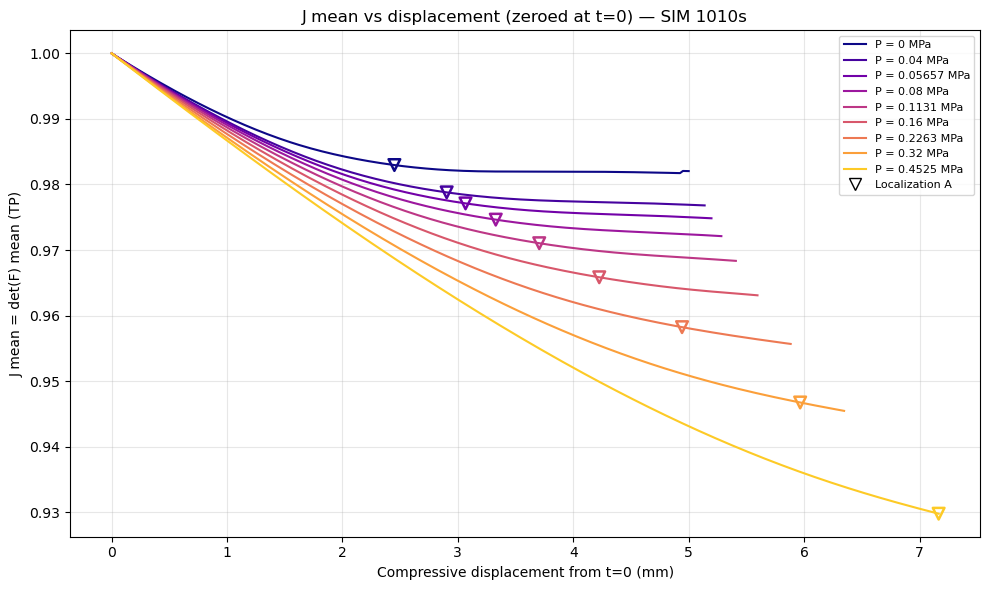

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in J_DISTORTION_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    J_mean = J_DISTORTION_CACHE[sim]['J_mean']

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, J_mean, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, J_mean)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('J mean = det(F) mean (TP)')
ax.set_title('J mean vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 6 — Distortion mean (distortional part) vs compressive displacement from t=0

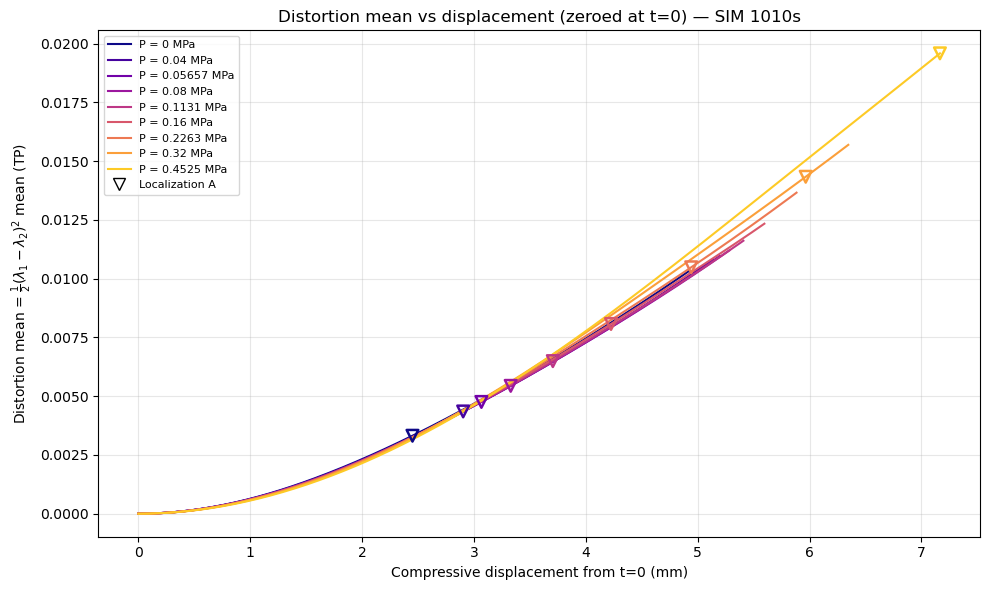

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in J_DISTORTION_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    distortion_mean = J_DISTORTION_CACHE[sim]['distortion_mean']

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, distortion_mean, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, distortion_mean)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel(r'Distortion mean = $\frac{1}{2}(\lambda_1-\lambda_2)^2$ mean (TP)')
ax.set_title('Distortion mean vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 7 — eta_shear (area-weighted shear homogeneity) vs compressive displacement from t=0

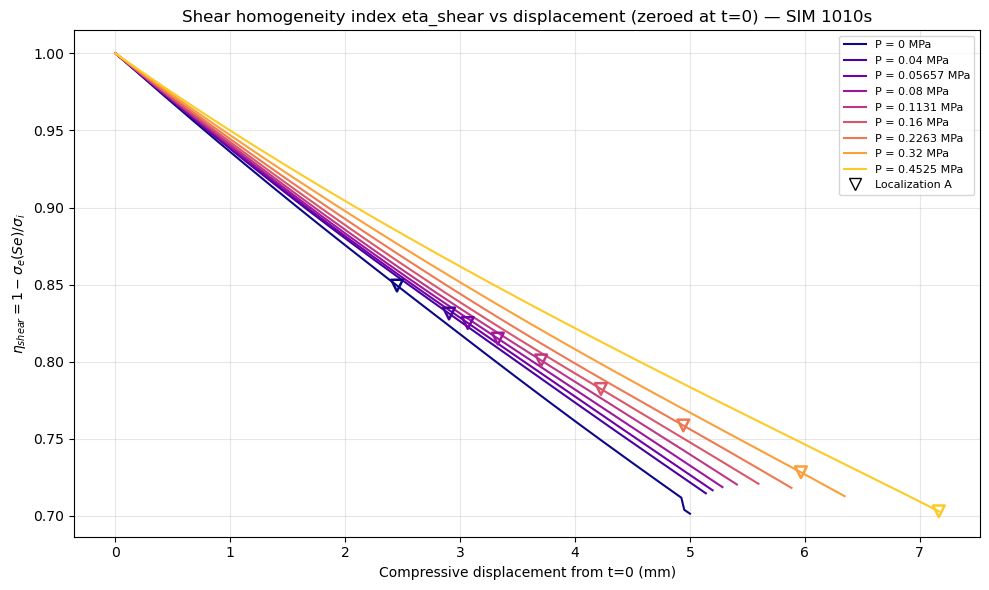

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    eta_shear  = np.array(tp2l['eta_shear'])
    del a2, tp2l

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, eta_shear, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, eta_shear)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel(r'$\eta_{shear} = 1 - \sigma_e(Se)/\sigma_i$')
ax.set_title('Shear homogeneity index eta_shear vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 8 — eta (element-area homogeneity) vs compressive displacement from t=0

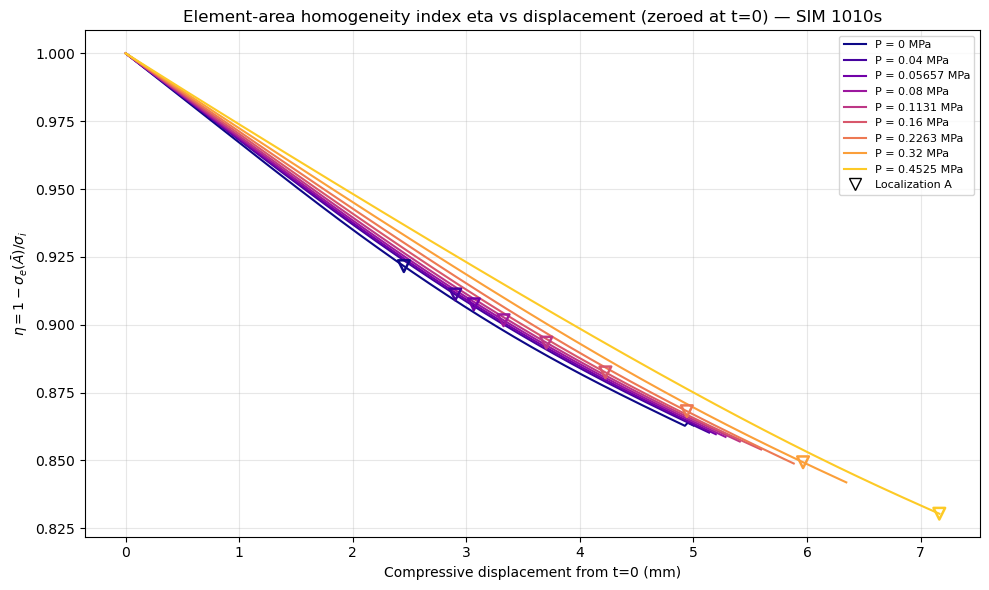

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    eta   = np.array(tp2l['eta'])
    del a2, tp2l

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, eta, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, eta)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel(r'$\eta = 1 - \sigma_e(\bar{A})/\sigma_i$')
ax.set_title('Element-area homogeneity index eta vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 9 — etaC_A, etaC_R (hole-based localization indices) vs compressive displacement from t=0

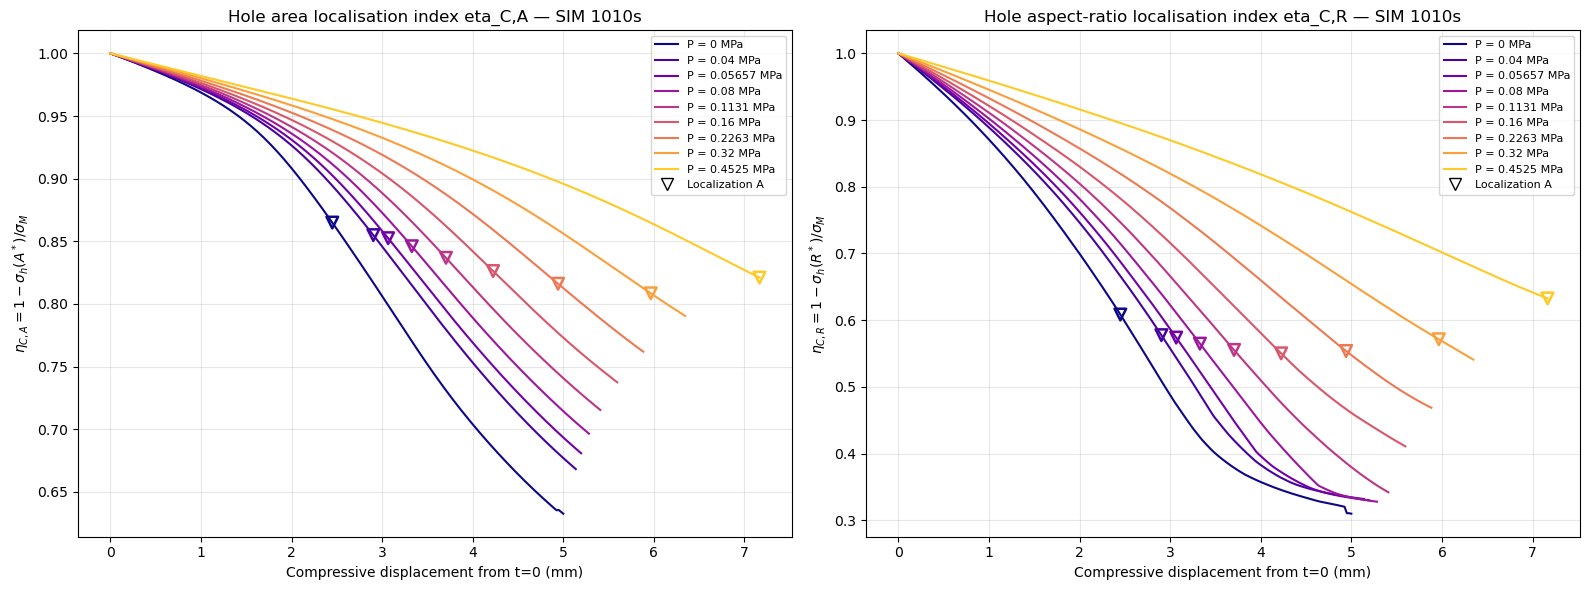

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    defc2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_DEFC2.pkl'))
    if defc2 is None:
        continue
    # displacement here matches A2's U2 sign convention (signed, decreasing).
    displ  = -np.array(defc2['displacement'])
    etaC_A = np.array(defc2['etaC_A'])
    etaC_R = np.array(defc2['etaC_R'])
    del defc2

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax1.plot(displ_zero, etaC_A, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    ax2.plot(displ_zero, etaC_R, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA1 = np.interp(xA, displ_zero, etaC_A)
        yA2 = np.interp(xA, displ_zero, etaC_R)
        ax1.scatter(xA, yA1, marker='v', s=70, facecolor='none',
                    edgecolor=cmap(idx), linewidths=1.8, zorder=5)
        ax2.scatter(xA, yA2, marker='v', s=70, facecolor='none',
                    edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax1.set_xlabel('Compressive displacement from t=0 (mm)')
ax1.set_ylabel(r'$\eta_{C,A} = 1 - \sigma_h(A^*)/\sigma_M$')
ax1.set_title('Hole area localisation index eta_C,A — SIM 1010s')
ax1.legend(*add_localization_legend(ax1), loc='best', fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Compressive displacement from t=0 (mm)')
ax2.set_ylabel(r'$\eta_{C,R} = 1 - \sigma_h(R^*)/\sigma_M$')
ax2.set_title('Hole aspect-ratio localisation index eta_C,R — SIM 1010s')
ax2.legend(*add_localization_legend(ax2), loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


## Plot 10 — w_cv (strain-energy-density coefficient of variation) vs compressive displacement from t=0

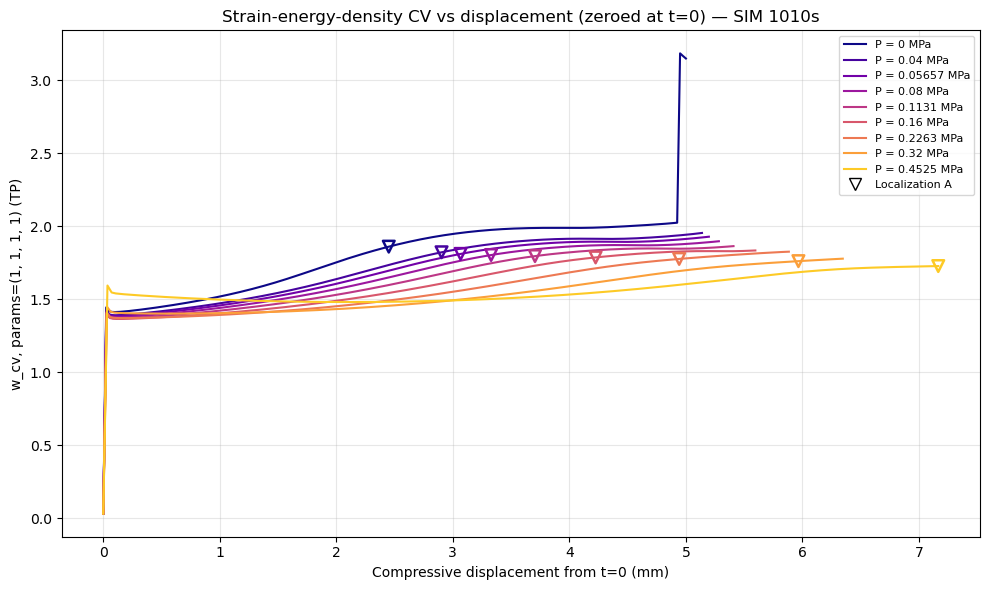

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))
W_PARAMS = (1, 1, 1, 1)

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    w_cv  = np.array(tp2l['w_cv'][W_PARAMS])
    del a2, tp2l

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, w_cv, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, w_cv)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel(f'w_cv, params={W_PARAMS} (TP)')
ax.set_title('Strain-energy-density CV vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 11 — f (tension/compression network efficiency ratio) vs compressive strain from t=0

`f(t) = global_ef_t(t) / global_ef_c(t)` from `DATA_PICK_{sim}_I3_BFS_3002.pkl` — the
ratio of average global efficiency of the tension bar network to the compression bar
network on the hexagonal overlay lattice. `f = 1` marks the frame where the skeleton's
mean stress crosses zero (see `docs/PRESSURE_LIMIT_STRAIN_AND_FACTOR_F.md`). Plotted on
a log y-axis since `f` spans several orders of magnitude within a run.

Strain uses the same zeroed convention as `SIM_1010s_analysis.ipynb`:
`strain = (displ - displ[0]) / (20 - displ[0])`, where `20 - displ[0]` is the specimen
height at the start of Step-1 (post pressure-expansion, pre-loading).

SIM 1010 (P = 0) is excluded from the `f = 1` story (`f(0) = 0` there, see doc caveat)
but is still plotted.

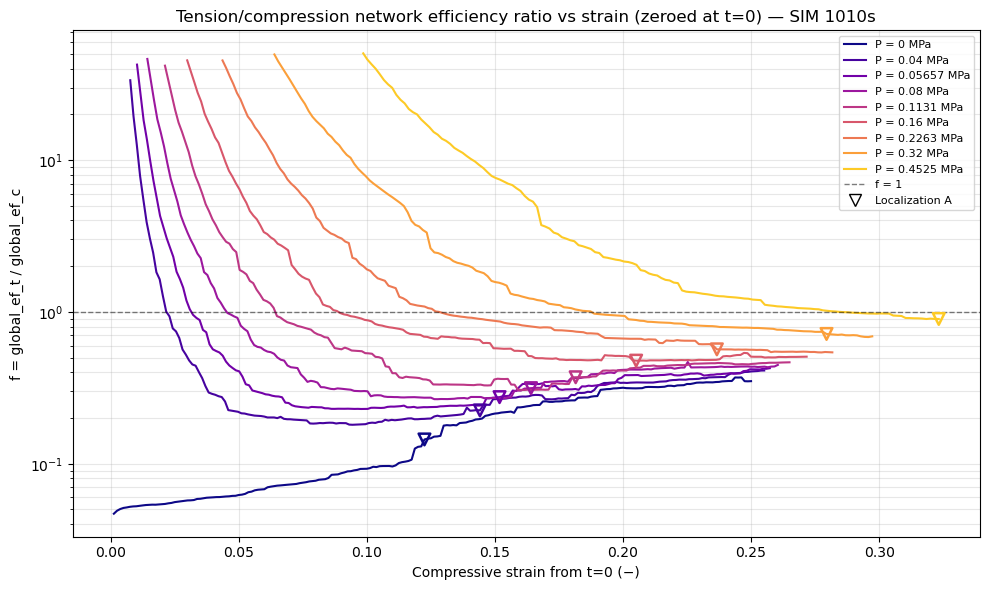

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2  = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    i3  = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
    if a2 is None or i3 is None:
        del a2, i3
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    ef_t  = np.array(i3['global_ef_t'], dtype=float)
    ef_c  = np.array(i3['global_ef_c'], dtype=float)
    del a2, i3

    with np.errstate(divide='ignore', invalid='ignore'):
        f_ratio = np.where(ef_c != 0, ef_t / ef_c, np.nan)
    del ef_t, ef_c

    # Compressive displacement from t=0, and the corresponding strain.
    # Original height at the start of Step-1 (post pressure-expansion,
    # pre-loading) = 20 - displ(t=0), since displ(t=0) is negative/zero.
    displ0     = displ[0]
    displ_zero = displ - displ0
    height0    = 20 - displ0
    strain     = displ_zero / height0

    mask = ~np.isnan(f_ratio) & (displ > 0)
    ax.plot(strain[mask], f_ratio[mask], color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = (LOC_A[sim] - displ0) / height0
        yA = np.interp(xA, strain[mask], f_ratio[mask])
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.axhline(1.0, color='k', linestyle='--', linewidth=1, alpha=0.5, label='f = 1')
ax.set_yscale('log')
ax.set_xlabel('Compressive strain from t=0 (−)')
ax.set_ylabel('f = global_ef_t / global_ef_c')
ax.set_title('Tension/compression network efficiency ratio vs strain (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
plt.show()

## Plot 12 — P/E vs strain at f = 1 (per sim)

`f = 1` marks the frame where the skeleton's mean stress crosses zero (the tension
backbone and compression backbone have equal global efficiency) — see
`docs/PRESSURE_LIMIT_STRAIN_AND_FACTOR_F.md` §2. For each sim, `eps(f=1)` is found by
walking the strain-ordered `f` curve and linearly interpolating the strain at the first
frame-to-frame crossing from `f >= 1` to `f < 1`.

`E` is read per sim from `OBJ_files/SIM_{sim}.json` (constant at 20 across this sweep).
SIM 1010 (P = 0) never crosses `f = 1` (`f` stays below 1 the whole run, see doc §6
caveat) and is excluded, matching the doc's own `e(f=1)` fit range (1011–1018).

In [19]:
def get_E(sim):
    path = resolve_path(os.path.join(OBJ_DIR, f'SIM_{sim:03d}.json'))
    if path is None:
        return None
    with open(path) as f:
        d = json.load(f)
    return float(d['E'])

loc_f1_data = []
for sim in SIMS:
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
    E  = get_E(sim)
    if a2 is None or i3 is None or sim not in PRESSURES or E is None:
        del a2, i3
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    ef_t  = np.array(i3['global_ef_t'], dtype=float)
    ef_c  = np.array(i3['global_ef_c'], dtype=float)
    del a2, i3

    with np.errstate(divide='ignore', invalid='ignore'):
        f_ratio = np.where(ef_c != 0, ef_t / ef_c, np.nan)
    del ef_t, ef_c

    mask = ~np.isnan(f_ratio) & (displ > 0)
    displ_m, f_m = displ[mask], f_ratio[mask]

    displ0  = displ[0]
    height0 = 20 - displ0
    strain_m = (displ_m - displ0) / height0

    # First frame-to-frame crossing from f >= 1 down to f < 1, linearly
    # interpolated in strain. None if f never crosses 1 (e.g. SIM 1010).
    eps_f1 = None
    for i in range(len(f_m) - 1):
        if f_m[i] >= 1 and f_m[i + 1] < 1:
            frac = (1 - f_m[i]) / (f_m[i + 1] - f_m[i])
            eps_f1 = strain_m[i] + frac * (strain_m[i + 1] - strain_m[i])
            break
    if eps_f1 is None:
        continue

    P = PRESSURES[sim]
    loc_f1_data.append(dict(sim=sim, P=P, E=E, P_over_E=P / E, eps_f1=eps_f1))

loc_f1_data.sort(key=lambda d: d['P_over_E'])
loc_f1_data

[{'sim': 1011,
  'P': 0.04,
  'E': 20.0,
  'P_over_E': 0.002,
  'eps_f1': 0.021760526115420172},
 {'sim': 1012,
  'P': 0.05656854249492381,
  'E': 20.0,
  'P_over_E': 0.0028284271247461905,
  'eps_f1': 0.03149213495312487},
 {'sim': 1013,
  'P': 0.08000000000000002,
  'E': 20.0,
  'P_over_E': 0.004000000000000001,
  'eps_f1': 0.04527077023363797},
 {'sim': 1014,
  'P': 0.11313708498984763,
  'E': 20.0,
  'P_over_E': 0.005656854249492382,
  'eps_f1': 0.06427206523760888},
 {'sim': 1015,
  'P': 0.16000000000000003,
  'E': 20.0,
  'P_over_E': 0.008000000000000002,
  'eps_f1': 0.08887785279813835},
 {'sim': 1016,
  'P': 0.2262741699796953,
  'E': 20.0,
  'P_over_E': 0.011313708498984765,
  'eps_f1': 0.12808459928685023},
 {'sim': 1017,
  'P': 0.3200000000000002,
  'E': 20.0,
  'P_over_E': 0.016000000000000007,
  'eps_f1': 0.18761657533615098},
 {'sim': 1018,
  'P': 0.45254833995939064,
  'E': 20.0,
  'P_over_E': 0.02262741699796953,
  'eps_f1': 0.28446560541727817}]

### Plot 12 (figure)

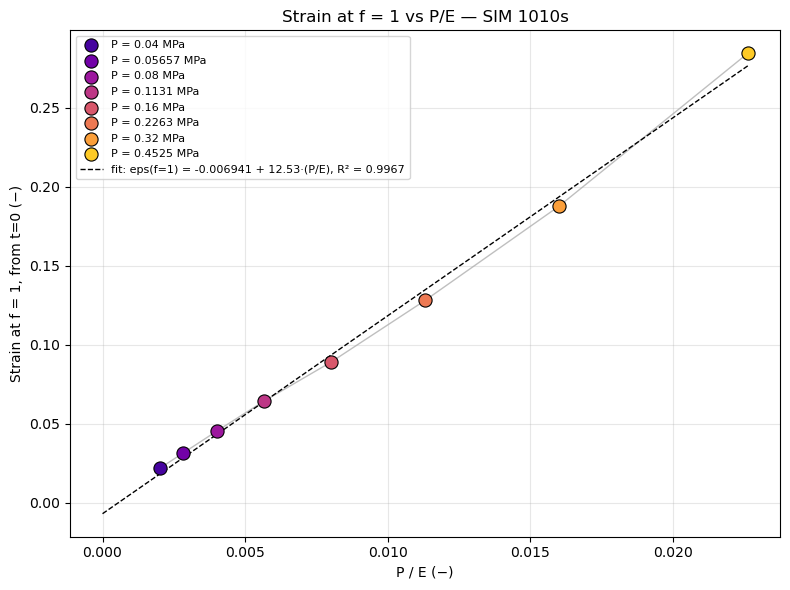

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    d = next((d for d in loc_f1_data if d['sim'] == sim), None)
    if d is None:
        continue
    ax.scatter(d['P_over_E'], d['eps_f1'], marker='o', s=90, color=cmap(idx),
               edgecolor='k', linewidths=0.8, zorder=5,
               label=f'P = {PRESSURES[sim]:.4g} MPa')

x = np.array([d['P_over_E'] for d in loc_f1_data])
y = np.array([d['eps_f1'] for d in loc_f1_data])
ax.plot(x, y, color='gray', linestyle='-', linewidth=1, alpha=0.5, zorder=1)

slope, intercept = np.polyfit(x, y, 1)
r2 = 1 - np.sum((y - (slope * x + intercept))**2) / np.sum((y - y.mean())**2)
xfit = np.linspace(0, x.max(), 50)
ax.plot(xfit, slope * xfit + intercept, color='k', linestyle='--', linewidth=1,
        label=f'fit: eps(f=1) = {intercept:.4g} + {slope:.4g}·(P/E), R² = {r2:.4f}')

ax.set_xlabel('P / E (−)')
ax.set_ylabel('Strain at f = 1, from t=0 (−)')
ax.set_title('Strain at f = 1 vs P/E — SIM 1010s')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## p (mean skeleton pressure) cache

`p_e(t) = -(S11_e(t) + S22_e(t)) / 2` per FEM element, from the raw `DATA_PICK_{sim}_B.pkl`
(Abaqus element stresses, integration-point resolved). Positive in compression, negative
in tension — same sign convention as `p0`/`p*` in `docs/SHEAR_PARAMETER_INTERPRETATION.md`.

`B.pkl` stores 8 rows per element (section-point duplicates of up to 4 integration
points, stride-2 pattern — see `fem_stress_interpolation._get_stress_at_integration_points`).
Averaging rows `0,2,4,6` gives the equal-weight barycenter value for quads (CPS4) and the
single constant value for triangles (CPS3, where all 8 rows are equal). Verified against
the doc: SIM 1013 mean p at t=0 computed here is -0.1251, doc table says -0.125.

Each `B.pkl` is ~1.2 GB (55k+ elements x 8 rows x 201 frames) so this is cached to
`p_cache_1010s.pkl` after the first run (~15-20s/sim to load + reduce).

For each sim this keeps: the full `mean_p(t)` curve (population mean across all elements,
every frame) and, at 5 landmark frames, the full per-element pressure snapshot (for the
histograms below):
- `t0` — frame 0
- `epsstar` — the Localization A frame (`argmin(shear_mean)`, same frame as `LOC_A`)
- `f1` — the frame closest to the `f = 1` crossing (see Plot 12)
- `mid` — the temporal midpoint of the run, `len(t)//2`
- `final` — the last frame

SIM 1010 (P = 0) has no `f1` landmark (`f` never crosses 1, see Plot 11/12 caveats) and is
skipped for that snapshot only; its `t0`/`epsstar`/`mid`/`final` snapshots are unaffected.

In [21]:
P_CACHE_PATH = 'p_cache_1010s.pkl'

def compute_p_cache():
    cache = {}
    for sim in SIMS:
        b_path = resolve_path(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_B.pkl'))
        a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
        if b_path is None or a2 is None:
            print(f'SIM {sim}: missing B or A2, skipping')
            continue
        print(f'SIM {sim}: loading B.pkl (~1.2 GB, ~15-20s)...')
        with open(b_path, 'rb') as f:
            b = pickle.load(f)

        t = np.array(b['t'])
        elem_ids = list(b['S11'].keys())
        s11_all = np.array([b['S11'][e] for e in elem_ids])   # (n_elem, 8, n_frames)
        s22_all = np.array([b['S22'][e] for e in elem_ids])
        del b

        p_ip = -(s11_all[:, 0::2, :] + s22_all[:, 0::2, :]) / 2.0   # (n_elem, 4, n_frames)
        p_e  = p_ip.mean(axis=1)                                   # (n_elem, n_frames)
        del s11_all, s22_all, p_ip

        mean_p_t = p_e.mean(axis=0)

        displ = -np.array(a2['U2']['PERN-9999997'])
        del a2

        idx_t0    = 0
        idx_final = len(t) - 1
        idx_mid   = len(t) // 2

        idx_epsstar = int(np.argmin(np.abs(displ - LOC_A[sim]))) if sim in LOC_A else None

        idx_f1 = None
        if i3 is not None:
            ef_t = np.array(i3['global_ef_t'], dtype=float)
            ef_c = np.array(i3['global_ef_c'], dtype=float)
            with np.errstate(divide='ignore', invalid='ignore'):
                f_ratio = np.where(ef_c != 0, ef_t / ef_c, np.nan)
            valid = np.where(~np.isnan(f_ratio) & (displ > 0))[0]
            for k in range(len(valid) - 1):
                i0, i1 = valid[k], valid[k + 1]
                if f_ratio[i0] >= 1 and f_ratio[i1] < 1:
                    idx_f1 = int(i0 if abs(f_ratio[i0] - 1) <= abs(f_ratio[i1] - 1) else i1)
                    break

        landmarks = {'t0': idx_t0, 'epsstar': idx_epsstar, 'f1': idx_f1,
                     'mid': idx_mid, 'final': idx_final}
        snapshots = {name: (p_e[:, idx].copy() if idx is not None else None)
                     for name, idx in landmarks.items()}

        cache[sim] = dict(t=t, mean_p=mean_p_t, landmarks=landmarks, snapshots=snapshots)
        del p_e
        print(f'SIM {sim}: done')
    return cache


if os.path.exists(P_CACHE_PATH):
    with open(P_CACHE_PATH, 'rb') as f:
        P_CACHE = pickle.load(f)
else:
    P_CACHE = compute_p_cache()
    with open(P_CACHE_PATH, 'wb') as f:
        pickle.dump(P_CACHE, f)

sorted(P_CACHE.keys())

SIM 1010: loading B.pkl (~1.2 GB, ~15-20s)...


SIM 1010: done
SIM 1011: loading B.pkl (~1.2 GB, ~15-20s)...


SIM 1011: done
SIM 1012: loading B.pkl (~1.2 GB, ~15-20s)...


SIM 1012: done
SIM 1013: loading B.pkl (~1.2 GB, ~15-20s)...


SIM 1013: done
SIM 1014: loading B.pkl (~1.2 GB, ~15-20s)...


...

SIM 1015: done
SIM 1016: loading B.pkl (~1.2 GB, ~15-20s)...


SIM 1016: done
SIM 1017: loading B.pkl (~1.2 GB, ~15-20s)...


SIM 1017: done
SIM 1018: loading B.pkl (~1.2 GB, ~15-20s)...


SIM 1018: done
SIM 1019: missing B or A2, skipping


[1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018]

## Plot 13 — Mean p (skeleton pressure) vs strain

Population mean of `p_e(t)` across all elements, plotted against the same zeroed strain
convention as Plots 11/12. `p < 0` at small strain for pressurized sims reflects the
biaxial pre-tension from internal gas pressure (§1/§3 of
`docs/PRESSURE_LIMIT_STRAIN_AND_FACTOR_F.md`); `p` rises through 0 as compression takes
over.

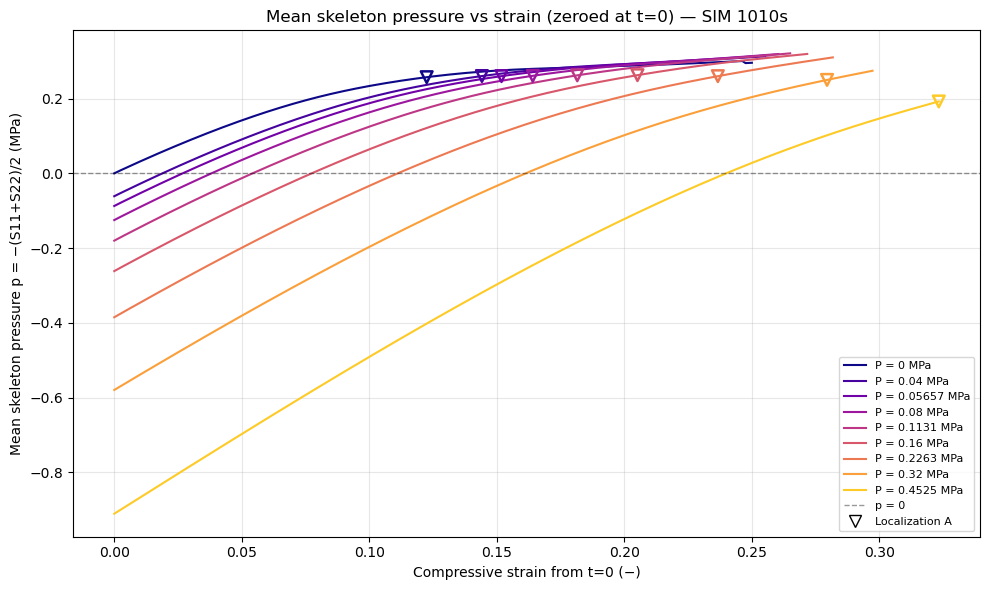

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in P_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    mean_p = P_CACHE[sim]['mean_p']

    displ0  = displ[0]
    height0 = 20 - displ0
    strain  = (displ - displ0) / height0

    ax.plot(strain, mean_p, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = (LOC_A[sim] - displ0) / height0
        yA = np.interp(xA, strain, mean_p)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.4, label='p = 0')
ax.set_xlabel('Compressive strain from t=0 (−)')
ax.set_ylabel('Mean skeleton pressure p = −(S11+S22)/2 (MPa)')
ax.set_title('Mean skeleton pressure vs strain (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Plot 14 — Distribution of element pressure at 5 landmark frames

One figure per landmark, all 9 sims overlaid as unfilled step histograms (density-
normalized, shared bin edges per landmark), colored by pressure — same convention as
every other plot in this notebook. Landmarks: `t = 0`, `ε = ε*` (Localization A),
`f = 1`, the temporal midpoint of the run, and the final frame. SIM 1010 has no `f = 1`
landmark and is omitted from that one panel only.

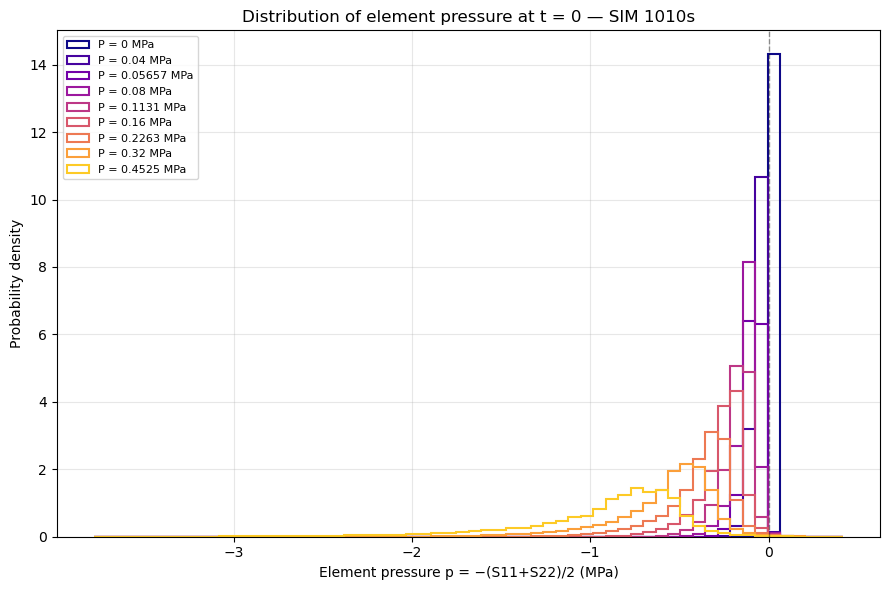

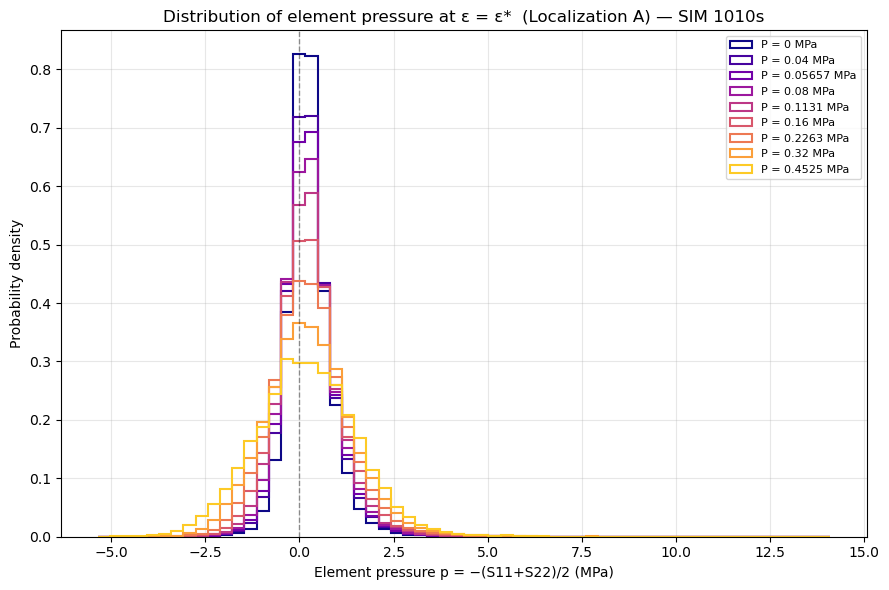

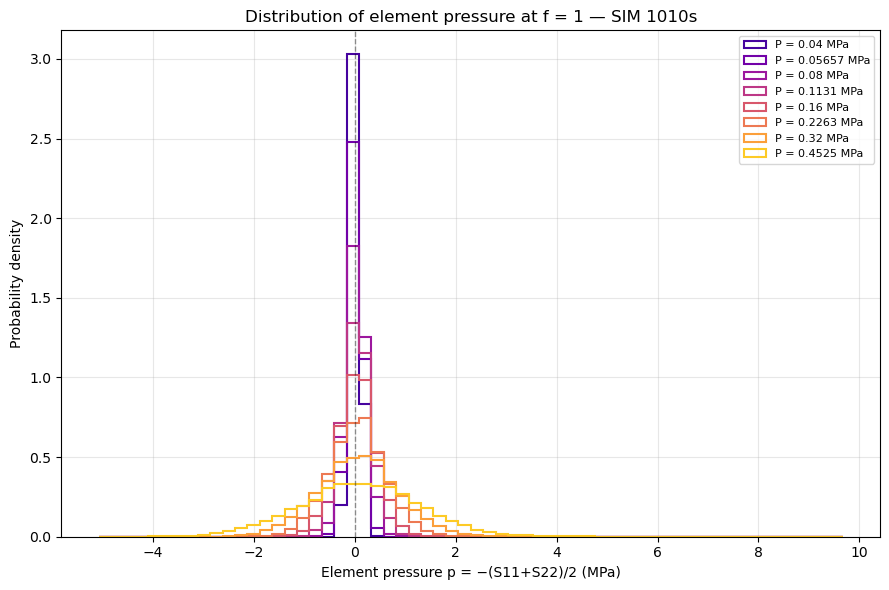

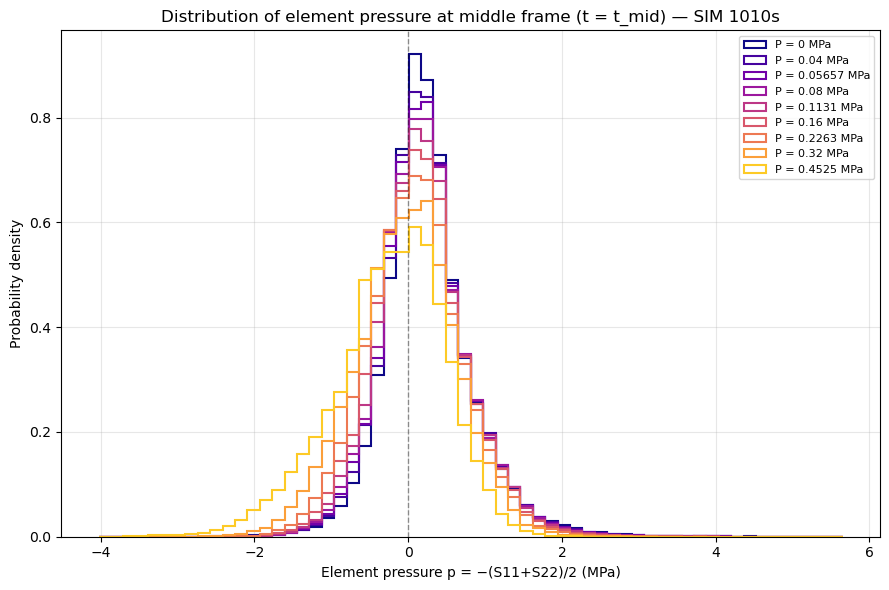

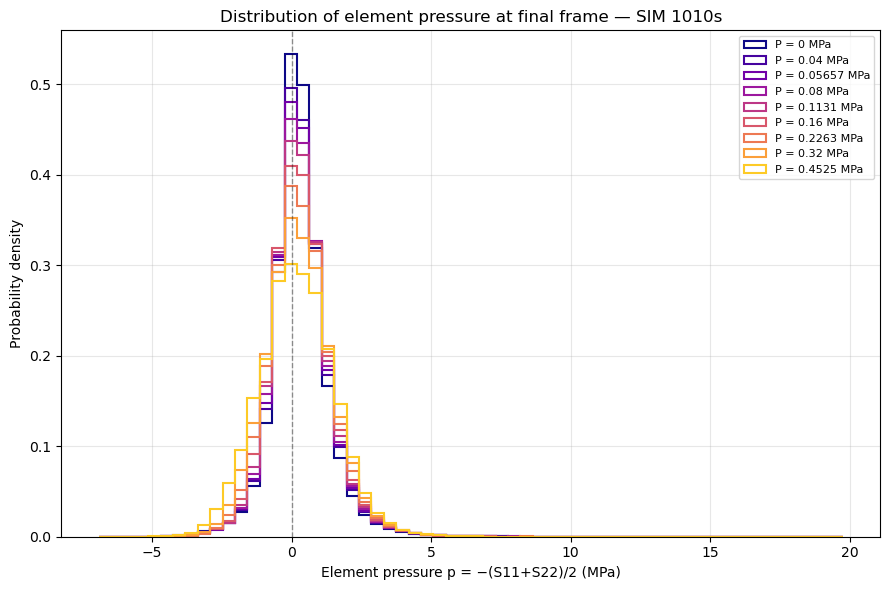

In [23]:
LANDMARK_LABELS = {
    't0':      't = 0',
    'epsstar': 'ε = ε*  (Localization A)',
    'f1':      'f = 1',
    'mid':     'middle frame (t = t_mid)',
    'final':   'final frame',
}

cmap = plt.get_cmap('plasma', len(SIMS))

for name, label in LANDMARK_LABELS.items():
    vals_by_sim = {sim: P_CACHE[sim]['snapshots'].get(name)
                   for sim in SIMS if sim in P_CACHE and P_CACHE[sim]['snapshots'].get(name) is not None}
    if not vals_by_sim:
        continue

    all_vals = np.concatenate(list(vals_by_sim.values()))
    bins = np.linspace(all_vals.min(), all_vals.max(), 61)

    fig, ax = plt.subplots(figsize=(9, 6))
    for idx, sim in enumerate(SIMS):
        if sim not in vals_by_sim:
            continue
        ax.hist(vals_by_sim[sim], bins=bins, histtype='step', density=True, linewidth=1.5,
                color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')

    ax.axvline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.4)
    ax.set_xlabel('Element pressure p = −(S11+S22)/2 (MPa)')
    ax.set_ylabel('Probability density')
    ax.set_title(f'Distribution of element pressure at {label} — SIM 1010s')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()